y_HY3 shape: (909, 1)
y_HY4_3 shape: (909, 1)


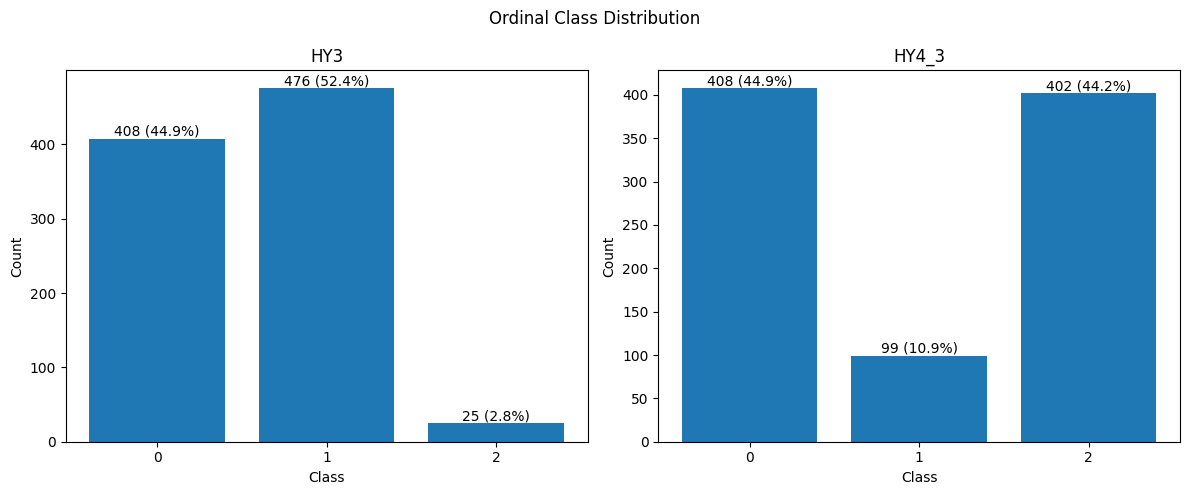

In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv", index_col=0)
print("y_HY3 shape:", y_HY3.shape)
print("y_HY4_3 shape:", y_HY43.shape)


datasets = {
    "HY3": y_HY3,
    'HY4_3': y_HY43,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files 

In [2]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples= { 'X_STATS':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS.csv', 
                    'X_V06_STATS': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+STATS.csv',
                      'X_V06_DELTA': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+Deltas.csv'}

y_multiples = { 'HY3': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv',
                'HY43': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv',
                'HY2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY2.csv'
                }



targets = ["HY3", "HY43"]
domains = ["FULL_PPMI", "UPDRS"]
structures = ["X_STATS", "X_V06_STATS", "X_V06_DELTA"]
experiments = ["Default", "Feature_Selection", "Optimization"]

output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/"

dominios_full = {
    'X_STATS': { 
        'motor': full_domain['SC_data'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['NM_data_STATS']
    },

    'X_V06_STATS': {
        'motor': full_domain['SC_data'] +full_domain['M_data_V06'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['SC_data'] + full_domain['NM_data_V06'] + full_domain['NM_data_STATS']
    },

    'X_V06_DELTA': {
        'motor': full_domain['SC_data'] + full_domain['M_data_V06'] + full_domain['M_data_DELTA'],
        'non_motor': full_domain['NM_data_V06'] + full_domain['NM_data_DELTA']
    }
}

dominios_updrs = {
    'X_STATS': {

        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_STATS': {
        
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_DELTA': {
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_delta'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_delta'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_delta']
    }
}

cols_updrs_full={}
for val in dominios_updrs:
    cols_updrs_val=[]
    for val_sub in dominios_updrs[val]:
        print(f"Evaluating domain: {val} - {val_sub}")
        cols_updrs_val+=dominios_updrs[val][val_sub]
    cols_updrs_full[val]=cols_updrs_val

cols_updrs_full['X_V06_STATS']=list(set(cols_updrs_full['X_V06_STATS']))
cols_updrs_full['X_STATS']=list(set(cols_updrs_full['X_STATS']))
cols_updrs_full['X_V06_DELTA']=list(set(cols_updrs_full['X_V06_DELTA']))


Evaluating domain: X_STATS - examen_motor
Evaluating domain: X_STATS - impacto_motor
Evaluating domain: X_STATS - non_motor
Evaluating domain: X_V06_STATS - examen_motor
Evaluating domain: X_V06_STATS - impacto_motor
Evaluating domain: X_V06_STATS - non_motor
Evaluating domain: X_V06_DELTA - examen_motor
Evaluating domain: X_V06_DELTA - impacto_motor
Evaluating domain: X_V06_DELTA - non_motor


# Models Baseline

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


classification_models_WB = {

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
        # aquí NO va class_weight
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}
# Diccionario con MinMaxScaler
models_minmax = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}

# Diccionario con StandardScaler
models_standard = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}

models_LDA = {
    "LDA_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto")),
        ("model", model)
    ])
    for name, model in classification_models_WB.items()
}

# ==================
# Regulation models
# ==================

classification_models_reg = {

    "decision_tree_REG": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=4,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        ccp_alpha=0.005
    ),

    "random_forest_REG": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        n_estimators=300,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        bootstrap=True
    ),

    "extra_trees_REG": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
        n_estimators=300,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        bootstrap=False
    ),

    "xgboost_REG": XGBClassifier(
        tree_method="hist",
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42,
        n_estimators=150,
        max_depth=3,
        learning_rate=0.03,
        min_child_weight=8,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=3.0,
        gamma=1.0
    ),

    "adaboost_REG": AdaBoostClassifier(
        algorithm="SAMME",
        random_state=42,
        n_estimators=100,
        learning_rate=0.05
    ),

    "svm_REG": SVC(
        kernel="rbf",
        probability=True,
        random_state=42,
        class_weight="balanced",
        C=0.3,
        gamma="scale"
    ),

    "logistic_regression_REG": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight="balanced",
        C=0.1,
        penalty="l2",
        solver="lbfgs"
    ),

    "knn_REG": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        p=2,
    ),

    "gaussian_nb_REG": GaussianNB(
        var_smoothing=1e-7
    )
}



models_LDA_reg = {
    "LDA_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(solver="eigen", shrinkage="auto")),
        ("model", model)
    ])
    for name, model in classification_models_reg.items()
}

models_minmax_reg = {
    "minmax_" + name: Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", model)
    ])
    for name, model in classification_models_reg.items()
}

models_standard_reg = {
    "standard_" + name: Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    for name, model in classification_models_reg.items()
}


models_no_scaling = classification_models_reg | classification_models_WB
models_minmax = models_minmax_reg | models_minmax
models_standard = models_standard_reg | models_standard
models_LDA = models_LDA_reg | models_LDA

# Model Performance Function

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    precision_recall_fscore_support,
)


def _compute_metrics_multiclass(
    y_true,
    y_pred,
    y_proba=None,
    class_labels=None,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    if class_labels is None:
        class_labels = np.unique(np.concatenate([y_true, y_pred]))

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)

    # ---- misclassification disease cost ----
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1, 10],
            [5, 0, 1],
            [10, 3, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_disease_cost_mean"] = sample_costs.mean()
    metrics["misclassification_disease_cost_total"] = sample_costs.sum()
    metrics["misclassification_disease_score"] = -sample_costs.mean()

    for cls in class_labels:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = np.nan

    # ---- AUC multiclass ----
    if y_proba is not None:
        try:
            metrics["auc_ovr_macro"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["auc_ovr_weighted"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["auc_ovr_macro"] = np.nan
            metrics["auc_ovr_weighted"] = np.nan
    else:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    for i, cls in enumerate(class_labels):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # ---- directed confusion metrics for classes 0, 1, 2 ----
    for cls in [0, 1, 2]:
        mask_cls = (y_true == cls)
        wrong_cls = mask_cls & (y_pred != cls)

        if mask_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.mean(y_pred[mask_cls] == other_cls)
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.nan

        if wrong_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = np.mean(
                        y_pred[wrong_cls] == other_cls
                    )
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.nanmean([m[k] for m in metrics_list]) for k in keys}


def _std_metrics(metrics_list):
    keys = metrics_list[0].keys()
    out = {}
    for k in keys:
        vals = np.array([m[k] for m in metrics_list], dtype=float)
        if len(vals) > 1:
            out[k] = np.nanstd(vals, ddof=1)
        else:
            out[k] = 0.0
    return out


# =========================
# BUILD FINAL ROW
# =========================
def _build_row_multiclass(results, model_name, class_labels):
    metric_names = list(results[0]["train"].keys())

    row = {
        "model": model_name,
        "target_type": "multiclass",
        "classes": list(class_labels),
        "n_classes": len(class_labels),
    }

    for metric in metric_names:
        train_vals = [r["train"][metric] for r in results]
        val_vals = [r["val"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_train_mean"] = np.nanmean(train_vals)
        row[f"{metric}_train_std"] = np.nanstd(train_vals, ddof=1) if len(train_vals) > 1 else 0.0

        row[f"{metric}_val_mean"] = np.nanmean(val_vals)
        row[f"{metric}_val_std"] = np.nanstd(val_vals, ddof=1) if len(val_vals) > 1 else 0.0

        row[f"{metric}_test_mean"] = np.nanmean(test_vals)
        row[f"{metric}_test_std"] = np.nanstd(test_vals, ddof=1) if len(test_vals) > 1 else 0.0

    return row


# =========================
# MAIN FUNCTION
# =========================
def evaluate_model_10x10_metrics_multiclass(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = y_arr.ravel()

    class_labels = np.unique(y_arr)
    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_train_scores = []
            inner_val_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                # TRAIN INNER
                y_pred_train_inner = est.predict(X_train_inner)
                y_proba_train_inner = (
                    est.predict_proba(X_train_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                train_scores_inner = _compute_metrics_multiclass(
                    y_true=y_train_inner,
                    y_pred=y_pred_train_inner,
                    y_proba=y_proba_train_inner,
                    class_labels=class_labels
                )

                # VAL INNER
                y_pred_val = est.predict(X_val_inner)
                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                val_scores_inner = _compute_metrics_multiclass(
                    y_true=y_val_inner,
                    y_pred=y_pred_val,
                    y_proba=y_proba_val,
                    class_labels=class_labels
                )

                inner_train_scores.append(train_scores_inner)
                inner_val_scores.append(val_scores_inner)

            train_mean_scores = _mean_metrics(inner_train_scores)
            val_mean_scores = _mean_metrics(inner_val_scores)

            # =========================
            # FINAL MODEL (OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_pred_test = final_model.predict(X_test_outer)
            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_multiclass(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                class_labels=class_labels
            )

            results.append({
                "train": train_mean_scores,
                "val": val_mean_scores,
                "test": test_scores
            })

        row = _build_row_multiclass(
            results=results,
            model_name=model_name,
            class_labels=class_labels,
        )

        print(
            f"\tresults -> "
            f"f1_macro_train={row['f1_macro_train_mean']:.4f}, "
            f"f1_macro_val={row['f1_macro_val_mean']:.4f}, "
            f"f1_macro_test={row['f1_macro_test_mean']:.4f}"
        )

        all_rows.append(row)

    return pd.DataFrame(all_rows)

# Model Performance

In [5]:
# UPDERS DOMAINS
list_results = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)[cols_updrs_full[val]]
    print(f"    Shape in X: {X.shape}")
    for target in ['HY43','HY3']:
        print(f"    Evaluating target: {target}")
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)

        for scaler in ['None','MINMAX','STANDARD','LDA']:
            if scaler == 'None':
                model_dict_use = models_no_scaling
            if scaler == 'MINMAX':
                model_dict_use = models_minmax
            if scaler == 'STANDARD':
                model_dict_use = models_standard
            if scaler == 'LDA':
                model_dict_use = models_LDA

            df=evaluate_model_10x10_metrics_multiclass(model_dict=model_dict_use, 
                                                X=X, 
                                                y=y)
            df['X_transfromation'] = scaler
            df['Target'] = target
            df['X_Processing'] = val
            list_results.append(df)
        
df_final=pd.concat(list_results, ignore_index=True)
df_final.to_csv(f'{output_path}/Multiclass_UPDRS_Default_and_Scalers_results.csv', index=False)
df_final
       

Evaluating domain: X_STATS
    Shape in X: (909, 301)
    Evaluating target: HY43
Evaluating model: decision_tree_REG
	results -> f1_macro_train=0.6928, f1_macro_val=0.6229, f1_macro_test=0.6376
Evaluating model: random_forest_REG
	results -> f1_macro_train=0.8656, f1_macro_val=0.6863, f1_macro_test=0.6947
Evaluating model: extra_trees_REG
	results -> f1_macro_train=0.8759, f1_macro_val=0.6921, f1_macro_test=0.7024
Evaluating model: xgboost_REG
	results -> f1_macro_train=0.7060, f1_macro_val=0.6144, f1_macro_test=0.6292
Evaluating model: adaboost_REG
	results -> f1_macro_train=0.6015, f1_macro_val=0.5927, f1_macro_test=0.5997
Evaluating model: svm_REG
	results -> f1_macro_train=0.6238, f1_macro_val=0.6036, f1_macro_test=0.6277
Evaluating model: logistic_regression_REG
	results -> f1_macro_train=0.9079, f1_macro_val=0.6449, f1_macro_test=0.6516
Evaluating model: knn_REG
	results -> f1_macro_train=1.0000, f1_macro_val=0.5662, f1_macro_test=0.5726
Evaluating model: gaussian_nb_REG
	result

,model,target_type,classes,n_classes,accuracy_train_mean,accuracy_train_std,accuracy_val_mean,accuracy_val_std,accuracy_test_mean,accuracy_test_std,...,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_train_mean,conf_2_to_1_given_error_train_std,conf_2_to_1_given_error_val_mean,conf_2_to_1_given_error_val_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,X_transfromation,Target,X_Processing
0,decision_tree_REG,multiclass,"[0, 1, 2]",3,0.762157,0.019644,0.707539,0.021322,0.725275,0.067653,...,0.132889,0.832442,0.035138,0.819656,0.047026,0.842641,0.132889,None,HY43,X_STATS
1,random_forest_REG,multiclass,"[0, 1, 2]",3,0.916539,0.002243,0.834241,0.005826,0.837363,0.013618,...,0.066772,0.519760,0.070394,0.658705,0.070940,0.755161,0.066772,None,HY43,X_STATS
2,extra_trees_REG,multiclass,"[0, 1, 2]",3,0.919551,0.003411,0.828168,0.007157,0.831136,0.017816,...,0.062844,0.596730,0.058106,0.735978,0.052860,0.806417,0.062844,None,HY43,X_STATS
3,xgboost_REG,multiclass,"[0, 1, 2]",3,0.885034,0.004501,0.851571,0.006550,0.860806,0.010216,...,0.133781,0.022381,0.023311,0.107067,0.080514,0.110516,0.133781,None,HY43,X_STATS
4,adaboost_REG,multiclass,"[0, 1, 2]",3,0.853753,0.005739,0.840314,0.008204,0.850183,0.009836,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,None,HY43,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427,LDA_adaboost,multiclass,"[0, 1, 2]",3,0.942427,0.007089,0.865759,0.008758,0.865201,0.020562,...,0.063246,0.835000,0.105541,0.994167,0.012454,0.980000,0.063246,LDA,HY3,X_V06_DELTA
428,LDA_svm,multiclass,"[0, 1, 2]",3,0.926539,0.006610,0.851990,0.009543,0.845055,0.028165,...,0.105541,0.250000,0.201384,0.876667,0.122020,0.935000,0.105541,LDA,HY3,X_V06_DELTA
429,LDA_logistic_regression,multiclass,"[0, 1, 2]",3,0.927303,0.006873,0.854764,0.009311,0.844689,0.016308,...,0.182244,0.420000,0.257337,0.901667,0.108994,0.871667,0.182244,LDA,HY3,X_V06_DELTA
430,LDA_knn,multiclass,"[0, 1, 2]",3,0.948427,0.004215,0.876230,0.006951,0.875092,0.011382,...,0.093002,0.989167,0.024861,0.990000,0.017480,0.929048,0.093002,LDA,HY3,X_V06_DELTA


In [8]:
df_final=pd.read_csv(f'{output_path}/Multiclass_UPDRS_Default_and_Scalers_results.csv', keep_default_na=False)
df_final

model_type = {'decision_tree':['decision_tree', 'minmax_decision_tree', 'standard_decision_tree', 'LDA_decision_tree','decision_tree_REG', 'minmax_decision_tree_REG', 'standard_decision_tree_REG', 'LDA_decision_tree_REG'],
              'random_forest': ['random_forest', 'minmax_random_forest', 'standard_random_forest', 'LDA_random_forest', 'random_forest_REG', 'minmax_random_forest_REG', 'standard_random_forest_REG', 'LDA_random_forest_REG'],
              'extra_trees': ['extra_trees', 'minmax_extra_trees', 'standard_extra_trees', 'LDA_extra_trees', 'extra_trees_REG', 'minmax_extra_trees_REG', 'standard_extra_trees_REG', 'LDA_extra_trees_REG'],
              'xgboost': ['xgboost', 'minmax_xgboost', 'standard_xgboost', 'LDA_xgboost', 'xgboost_REG', 'minmax_xgboost_REG', 'standard_xgboost_REG', 'LDA_xgboost_REG'],
              'adaboost': ['adaboost', 'minmax_adaboost', 'standard_adaboost', 'LDA_adaboost', 'adaboost_REG', 'minmax_adaboost_REG', 'standard_adaboost_REG', 'LDA_adaboost_REG'],
              'svm': ['svm', 'minmax_svm', 'standard_svm', 'LDA_svm', 'svm_REG', 'minmax_svm_REG', 'standard_svm_REG', 'LDA_svm_REG'],
              'logistic_regression': ['logistic_regression', 'minmax_logistic_regression', 'standard_logistic_regression', 'LDA_logistic_regression', 'logistic_regression_REG', 'minmax_logistic_regression_REG', 'standard_logistic_regression_REG', 'LDA_logistic_regression_REG'],
              'knn': ['knn', 'minmax_knn', 'standard_knn', 'LDA_knn', 'knn_REG', 'minmax_knn_REG', 'standard_knn_REG', 'LDA_knn_REG'],
              'gaussian_nb': ['gaussian_nb', 'minmax_gaussian_nb', 'standard_gaussian_nb', 'LDA_gaussian_nb', 'gaussian_nb_REG', 'minmax_gaussian_nb_REG', 'standard_gaussian_nb_REG', 'LDA_gaussian_nb_REG']}

df_final['Model_Type'] = df_final['model'].apply(lambda x: next((key for key, values in model_type.items() if x in values)))

final_list = []
for target in df_final['Target'].unique():
    if target == 'HY3':
        special_col1 = 'f1_class_2_val_mean'
        special_col2 = 'f1_class_2_test_mean'
    elif target == 'HY43':
        special_col1 = 'f1_class_1_val_mean'
        special_col2 = 'f1_class_1_test_mean'

    list_results_target = []
    for model_type in df_final['Model_Type'].unique():
        subset = df_final[(df_final['Target'] == target) & (df_final['Model_Type'] == model_type)]
        print(f"Target: {target}, Model Type: {model_type}")
        # print(subset[['model','X_Processing','f1_macro_test_mean', 'f1_macro_cv_mean', special_col1, special_col2]].sort_values(by=special_col1, ascending=False))
        best_row = subset.loc[subset[special_col1].idxmax()]
        print(f"Best model for {target} in {model_type}: {best_row['model']} with {special_col1}={best_row[special_col1]:.4f} AND {special_col2}={best_row[special_col2]:.4f}")
        print("\n")
        list_results_target.append(best_row)
    df_best = pd.DataFrame(list_results_target)
    final_list.append(df_best)

#final_list[1].to_csv(f'{output_path}/Best_Models_HY3_phase1.csv', index=False)
#final_list[0].to_csv(f'{output_path}/Best_Models_HY43_phase1.csv', index=False)

Target: HY43, Model Type: decision_tree
Best model for HY43 in decision_tree: decision_tree_REG with f1_class_1_val_mean=0.2806 AND f1_class_1_test_mean=0.2862


Target: HY43, Model Type: random_forest
Best model for HY43 in random_forest: minmax_random_forest_REG with f1_class_1_val_mean=0.3177 AND f1_class_1_test_mean=0.3810


Target: HY43, Model Type: extra_trees
Best model for HY43 in extra_trees: extra_trees_REG with f1_class_1_val_mean=0.3244 AND f1_class_1_test_mean=0.3558


Target: HY43, Model Type: xgboost
Best model for HY43 in xgboost: LDA_xgboost with f1_class_1_val_mean=0.1697 AND f1_class_1_test_mean=0.1527


Target: HY43, Model Type: adaboost
Best model for HY43 in adaboost: adaboost with f1_class_1_val_mean=0.2100 AND f1_class_1_test_mean=0.1861


Target: HY43, Model Type: svm
Best model for HY43 in svm: svm with f1_class_1_val_mean=0.3090 AND f1_class_1_test_mean=0.3443


Target: HY43, Model Type: logistic_regression
Best model for HY43 in logistic_regression: LDA_logi

In [76]:
print("Best models per target and model type:")
print('Models for HY43:')
HY43_phase1=pd.read_csv(f'{output_path}/Best_Models_HY43_phase1.csv',keep_default_na=False)
HY43_phase1.sort_values(by='f1_class_1_cv_mean', ascending=False)


Best models per target and model type:
Models for HY43:


,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,X_transfromation,Target,X_Processing,Model_Type
5,svm,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.763770,0.010926,0.784982,0.030356,0.656746,0.015330,...,0.154139,0.056553,0.793319,0.039080,0.845861,0.056553,None,HY43,X_STATS,svm
6,LDA_logistic_regression,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.746178,0.012337,0.748718,0.027531,0.647219,0.011874,...,0.124401,0.038455,0.861177,0.041454,0.875599,0.038455,LDA,HY43,X_V06_DELTA,logistic_regression
8,gaussian_nb,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.694974,0.025478,0.730037,0.053111,0.606178,0.014888,...,0.078809,0.039201,0.914251,0.036258,0.921191,0.039201,None,HY43,X_V06_DELTA,gaussian_nb
2,LDA_extra_trees,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.766597,0.007634,0.777656,0.015641,0.646359,0.012004,...,0.188978,0.069581,0.785077,0.043242,0.811022,0.069581,LDA,HY43,X_V06_STATS,extra_trees
0,LDA_decision_tree,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.697068,0.020623,0.704396,0.049024,0.608595,0.011956,...,0.113086,0.055182,0.883558,0.046695,0.886914,0.055182,LDA,HY43,X_V06_DELTA,decision_tree
1,LDA_random_forest,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.749843,0.013838,0.758974,0.030147,0.633551,0.013594,...,0.160175,0.051141,0.831292,0.046464,0.839825,0.051141,LDA,HY43,X_V06_DELTA,random_forest
4,adaboost,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.810471,0.006822,0.820879,0.016782,0.651473,0.012943,...,0.330121,0.106274,0.689666,0.063920,0.669879,0.106274,None,HY43,X_STATS,adaboost
3,xgboost,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.841571,0.005077,0.851282,0.012712,0.650230,0.012963,...,0.612925,0.205469,0.381840,0.088303,0.387075,0.205469,None,HY43,X_STATS,xgboost
7,minmax_knn,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.801780,0.010838,0.804396,0.022659,0.619905,0.015693,...,0.599746,0.116293,0.313288,0.070865,0.400254,0.116293,MINMAX,HY43,X_STATS,knn


In [78]:
print('Models for HY3:')
HY3_phase1=pd.read_csv(f'{output_path}/Best_Models_HY3_phase1.csv',keep_default_na=False)
HY3_phase1.sort_values(by='f1_class_2_cv_mean', ascending=False)

Models for HY3:


,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,X_transfromation,Target,X_Processing,Model_Type
6,minmax_logistic_regression,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.886806,0.004076,0.886447,0.014239,0.744638,0.021967,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,MINMAX,HY3,X_V06_DELTA,logistic_regression
8,LDA_gaussian_nb,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.876283,0.005236,0.878022,0.012093,0.735258,0.015627,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,LDA,HY3,X_V06_DELTA,gaussian_nb
7,LDA_knn,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.883560,0.006146,0.875458,0.014753,0.734629,0.023689,...,0.02,0.063246,0.993000,0.011353,0.98,0.063246,LDA,HY3,X_V06_STATS,knn
5,svm,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.777068,0.014195,0.789744,0.019627,0.658112,0.021101,...,0.00,0.000000,0.870000,0.115950,1.00,0.000000,None,HY3,X_V06_DELTA,svm
4,adaboost,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.869948,0.009521,0.869597,0.017111,0.718235,0.025552,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,None,HY3,X_V06_DELTA,adaboost
1,LDA_random_forest,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.854503,0.009699,0.851282,0.021992,0.704051,0.012344,...,0.00,0.000000,0.920000,0.063246,1.00,0.000000,LDA,HY3,X_V06_STATS,random_forest
2,LDA_extra_trees,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.839476,0.011669,0.840293,0.026256,0.691218,0.018430,...,0.05,0.158114,0.875000,0.092045,0.95,0.158114,LDA,HY3,X_V06_DELTA,extra_trees
0,LDA_decision_tree,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.816859,0.015071,0.819048,0.026085,0.667272,0.029579,...,0.02,0.063246,0.810833,0.142511,0.98,0.063246,LDA,HY3,X_V06_DELTA,decision_tree
3,xgboost,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.895445,0.005639,0.898901,0.012595,0.700377,0.022771,...,0.02,0.063246,0.987167,0.025252,0.98,0.063246,None,HY3,X_STATS,xgboost


# Feature selection

## Pipeline for HY3

In [42]:
classification_models_HY3 = {
    "decision_tree": models_minmax['minmax_decision_tree'],#
    "random_forest": models_LDA_reg['LDA_random_forest'],
    "extra_trees":  models_LDA_reg['LDA_extra_trees'],
    "xgboost": classification_models_WB['xgboost'],#
    "adaboost": classification_models_WB['adaboost'],#
    "svm": classification_models_WB['svm'],#
    "logistic_regression": models_minmax['minmax_logistic_regression'],#
    "knn": models_LDA_reg['LDA_knn'],
    "gaussian_nb": models_LDA_reg['LDA_gaussian_nb']}

X_processing_HY3={
    'decision_tree': 'X_V06_DELTA',
    'random_forest': 'X_V06_STATS',
    'extra_trees': 'X_V06_DELTA',
    'xgboost': 'X_STATS',
    'adaboost': 'X_V06_DELTA',
    'svm': 'X_V06_DELTA',
    'logistic_regression': 'X_V06_DELTA',
    'knn': 'X_V06_STATS',
    'gaussian_nb': 'X_V06_DELTA'
}

## Pipeline for HY43

In [43]:
classification_models_HY43 = {
    "decision_tree": models_LDA_reg['LDA_decision_tree'],
    "random_forest": models_LDA_reg['LDA_random_forest'],
    "extra_trees":  models_LDA_reg['LDA_extra_trees'],
    "xgboost": classification_models_WB['xgboost'],#
    "adaboost": classification_models_WB['adaboost'],#
    "svm": classification_models_WB['svm'],#
    "logistic_regression": models_LDA_reg['LDA_logistic_regression'],
    "knn": models_minmax['minmax_knn'],#
    "gaussian_nb": classification_models_WB['gaussian_nb']}#

X_processing_HY43={
    'decision_tree': 'X_V06_DELTA',
    'random_forest': 'X_V06_DELTA',
    'extra_trees': 'X_V06_STATS',
    'xgboost': 'X_STATS',
    'adaboost': 'X_STATS',
    'svm': 'X_STATS',
    'logistic_regression': 'X_V06_DELTA',
    'knn': 'X_STATS',
    'gaussian_nb': 'X_V06_DELTA'
}

## FEATURE SELECTION PIPELINES

In [35]:
# feature selection
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import VarianceThreshold


from scipy.stats import spearmanr
def spearman_selector(X, y):
    scores = []
    pvalues = []
    
    for i in range(X.shape[1]):
        corr, p = spearmanr(X[:, i], y)
        
        if np.isnan(corr):
            corr = 0.0
        if np.isnan(p):
            p = 1.0
        
        scores.append(abs(corr))
        pvalues.append(p)
    
    return np.array(scores), np.array(pvalues)

selected_models_HY3 = {
    k: v for k, v in classification_models_WB.items()
    if k in ["decision_tree", "xgboost", "adaboost", "svm", "logistic_regression"]
}

pipelines_full_domain_MI_HY3 = {
    f"{name}_MI": Pipeline([
        ("scaler",
         MinMaxScaler() if name in ["logistic_regression", "decision_tree"]
         else "passthrough"),
        
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", clone(model))
    ])
    for name, model in selected_models_HY3.items()
}

pipelines_full_domain_SP_HY3 = {
    f"{name}_SP": Pipeline([
        ("scaler",
         MinMaxScaler() if name in ["logistic_regression", "decision_tree"]
         else "passthrough"),
        
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", clone(model))
    ])
    for name, model in selected_models_HY3.items()
}

pipelines_feature_selection_HY3 = {**pipelines_full_domain_MI_HY3, **pipelines_full_domain_SP_HY3}


selected_models_HY43 = {
    k: v for k, v in classification_models_WB.items()
    if k in [ "xgboost", "adaboost", "svm", "knn", "gaussian_nb"]
}

pipelines_full_domain_MI_HY43 = {
    f"{name}_MI": Pipeline([
        ("scaler",
         MinMaxScaler() if name in ["knn"]
         else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectPercentile(mutual_info_classif, percentile=80)),
        ("model", clone(model))
    ])
    for name, model in selected_models_HY43.items()
}

pipelines_full_domain_SP_HY43 = {
    f"{name}_SP": Pipeline([
        ("scaler",
         MinMaxScaler() if name in ["knn"]
         else "passthrough"),
        ("selector0", VarianceThreshold(threshold=0.0)),
        ("selector1", SelectKBest(score_func=spearman_selector, k=200)),
        ("model", clone(model))
    ])
    for name, model in selected_models_HY43.items()
}

pipelines_feature_selection_HY43 = {**pipelines_full_domain_MI_HY43, **pipelines_full_domain_SP_HY43}


In [ ]:
dict_data={
    'HY3': {
        'pipelines': pipelines_feature_selection_HY3,
        'X_processing': X_processing_HY3
    },
    'HY43': {
        'pipelines': pipelines_feature_selection_HY43,
        'X_processing': X_processing_HY43
    }
}

results_list= []
for key in dict_data:
    print(f"Evaluating feature selection for target: {key}")
    pipelines = dict_data[key]['pipelines']
    X_processing = dict_data[key]['X_processing']
    y = pd.read_csv(y_multiples[key], index_col=0)
    for model in pipelines:
        model_name = re.sub(r'_(MI|SP)$', '', model)
        X_path = X_multiples[X_processing[model_name]]
        X = pd.read_csv(X_path, index_col=0)[cols_updrs_full[X_processing[model_name]]]
        
        df=evaluate_model_10x10_metrics_multiclass(model_dict={model: pipelines[model]},
                                                X=X,
                                                y=y)
        df['Target'] = key
        df['X_Processing'] = X_processing[model_name]
        df['X_transfromation'] = 'Feature_selection'
        df['Model_Type'] = model_name
        results_list.append(df)

df_feature_selection = pd.concat(results_list, ignore_index=True)
df_feature_selection.to_csv(f'{output_path}/Multiclass_UPDRS_Feature_Selection_results.csv', index=False)
df_feature_selection

Evaluating feature selection for target: HY3
Evaluating model: decision_tree_MI
	results -> f1_macro_cv=0.6352, f1_macro_test=0.6085,f1_class_1_cv_mean=0.8380,f1_class_2_cv_mean=0.2094
Evaluating model: xgboost_MI
	results -> f1_macro_cv=0.6983, f1_macro_test=0.7008,f1_class_1_cv_mean=0.8970,f1_class_2_cv_mean=0.2881
Evaluating model: adaboost_MI
	results -> f1_macro_cv=0.7250, f1_macro_test=0.7266,f1_class_1_cv_mean=0.8754,f1_class_2_cv_mean=0.4204
Evaluating model: svm_MI
	results -> f1_macro_cv=0.6548, f1_macro_test=0.6331,f1_class_1_cv_mean=0.7972,f1_class_2_cv_mean=0.2958
Evaluating model: logistic_regression_MI
	results -> f1_macro_cv=0.7437, f1_macro_test=0.7294,f1_class_1_cv_mean=0.8871,f1_class_2_cv_mean=0.4319
Evaluating model: decision_tree_SP
	results -> f1_macro_cv=0.6411, f1_macro_test=0.6135,f1_class_1_cv_mean=0.8373,f1_class_2_cv_mean=0.2287
Evaluating model: xgboost_SP
	results -> f1_macro_cv=0.6867, f1_macro_test=0.7088,f1_class_1_cv_mean=0.8941,f1_class_2_cv_mean=0.2

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_cv_std,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,Target,X_Processing,Base_Model
0,decision_tree_MI,multiclass,"[0, 1, 2]",3,0.830733,0.010122,0.821612,0.015058,0.635223,0.017978,...,0.039067,0.014286,0.045175,0.955167,0.039067,0.985714,0.045175,HY3,X_V06_DELTA,decision_tree
1,xgboost_MI,multiclass,"[0, 1, 2]",3,0.892356,0.005289,0.899267,0.011869,0.698339,0.020353,...,0.006325,0.020000,0.063246,0.998000,0.006325,0.980000,0.063246,HY3,X_STATS,xgboost
2,adaboost_MI,multiclass,"[0, 1, 2]",3,0.867592,0.009023,0.869963,0.014473,0.724979,0.030307,...,0.010541,0.000000,0.000000,0.996667,0.010541,1.000000,0.000000,HY3,X_V06_DELTA,adaboost
3,svm_MI,multiclass,"[0, 1, 2]",3,0.821518,0.029977,0.825641,0.061006,0.654799,0.025785,...,0.000000,0.000000,0.000000,0.910000,0.110050,1.000000,0.000000,HY3,X_V06_DELTA,svm
4,logistic_regression_MI,multiclass,"[0, 1, 2]",3,0.886492,0.004295,0.882418,0.014596,0.743679,0.018218,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,HY3,X_V06_DELTA,logistic_regression
5,decision_tree_SP,multiclass,"[0, 1, 2]",3,0.830576,0.014476,0.819414,0.021640,0.641149,0.031051,...,0.015020,0.000000,0.000000,0.979833,0.015020,1.000000,0.000000,HY3,X_V06_DELTA,decision_tree
6,xgboost_SP,multiclass,"[0, 1, 2]",3,0.889005,0.004497,0.890842,0.009583,0.686732,0.024327,...,0.007906,0.020000,0.063246,0.997500,0.007906,0.980000,0.063246,HY3,X_STATS,xgboost
7,adaboost_SP,multiclass,"[0, 1, 2]",3,0.866440,0.007472,0.871795,0.018028,0.719225,0.025878,...,0.031623,0.000000,0.000000,0.990000,0.031623,1.000000,0.000000,HY3,X_V06_DELTA,adaboost
8,svm_SP,multiclass,"[0, 1, 2]",3,0.805864,0.021817,0.809524,0.046941,0.673648,0.028191,...,0.000000,0.000000,0.000000,0.870000,0.125167,1.000000,0.000000,HY3,X_V06_DELTA,svm
9,logistic_regression_SP,multiclass,"[0, 1, 2]",3,0.887277,0.007750,0.882784,0.013706,0.746644,0.026412,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,HY3,X_V06_DELTA,logistic_regression


In [81]:
df_feature_selection=pd.read_csv(f'{output_path}/Multiclass_UPDRS_Feature_Selection_results.csv', keep_default_na=False)
df_feature_selection_HY3 = df_feature_selection[df_feature_selection['Target'] == 'HY3']
df_feature_selection_HY43 = df_feature_selection[df_feature_selection['Target'] == 'HY43']
selection_phase2_HY3 = pd.concat([df_feature_selection_HY3,HY3_phase1], ignore_index=True)
selection_phase2_HY43 = pd.concat([df_feature_selection_HY43,HY43_phase1], ignore_index=True)


In [ ]:
rows_list_HY3 = []
for model_type in selection_phase2_HY3['Model_Type'].unique():
    subset = selection_phase2_HY3[selection_phase2_HY3['Model_Type'] == model_type]
    best_row = subset.loc[subset['f1_class_2_cv_mean'].idxmax()]
    rows_list_HY3.append(best_row)
df_best_HY3_phase2 = pd.DataFrame(rows_list_HY3).sort_values(by='f1_class_2_cv_mean', ascending=False)
df_best_HY3_phase2.to_csv(f'{output_path}/Best_Models_HY3_phase2.csv', index=False)
df_best_HY3_phase2

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,Target,X_Processing,Model_Type,X_transfromation
9,logistic_regression_SP,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.887277,0.007750,0.882784,0.013706,0.746644,0.026412,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,HY3,X_V06_DELTA,logistic_regression,Feature_selection
18,LDA_gaussian_nb,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.876283,0.005236,0.878022,0.012093,0.735258,0.015627,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,HY3,X_V06_DELTA,gaussian_nb,LDA
2,adaboost_MI,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.867592,0.009023,0.869963,0.014473,0.724979,0.030307,...,0.00,0.000000,0.996667,0.010541,1.00,0.000000,HY3,X_V06_DELTA,adaboost,Feature_selection
17,LDA_knn,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.883560,0.006146,0.875458,0.014753,0.734629,0.023689,...,0.02,0.063246,0.993000,0.011353,0.98,0.063246,HY3,X_V06_STATS,knn,LDA
15,svm,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.777068,0.014195,0.789744,0.019627,0.658112,0.021101,...,0.00,0.000000,0.870000,0.115950,1.00,0.000000,HY3,X_V06_DELTA,svm,None
11,LDA_random_forest,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.854503,0.009699,0.851282,0.021992,0.704051,0.012344,...,0.00,0.000000,0.920000,0.063246,1.00,0.000000,HY3,X_V06_STATS,random_forest,LDA
12,LDA_extra_trees,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.839476,0.011669,0.840293,0.026256,0.691218,0.018430,...,0.05,0.158114,0.875000,0.092045,0.95,0.158114,HY3,X_V06_DELTA,extra_trees,LDA
10,LDA_decision_tree,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.816859,0.015071,0.819048,0.026085,0.667272,0.029579,...,0.02,0.063246,0.810833,0.142511,0.98,0.063246,HY3,X_V06_DELTA,decision_tree,LDA
1,xgboost_MI,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.892356,0.005289,0.899267,0.011869,0.698339,0.020353,...,0.02,0.063246,0.998000,0.006325,0.98,0.063246,HY3,X_STATS,xgboost,Feature_selection


In [ ]:
rows_list_HY43 = []
for model_type in selection_phase2_HY43['Model_Type'].unique():
    subset = selection_phase2_HY43[selection_phase2_HY43['Model_Type'] == model_type]
    best_row = subset.loc[subset['f1_class_2_cv_mean'].idxmax()]
    rows_list_HY43.append(best_row)
df_best_HY43_phase2 = pd.DataFrame(rows_list_HY43).sort_values(by='f1_class_2_cv_mean', ascending=False)
df_best_HY43_phase2.to_csv(f'{output_path}/Best_Models_HY43_phase2.csv', index=False)
df_best_HY43_phase2

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,Target,X_Processing,Model_Type,X_transfromation
13,xgboost,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.841571,0.005077,0.851282,0.012712,0.650230,0.012963,...,0.612925,0.205469,0.381840,0.088303,0.387075,0.205469,HY43,X_STATS,xgboost,None
7,svm_SP,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.813822,0.008590,0.813919,0.022567,0.672490,0.005983,...,0.201552,0.043621,0.753686,0.045294,0.798448,0.043621,HY43,X_STATS,svm,Feature_selection
8,knn_SP,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.810471,0.010775,0.817949,0.018682,0.625653,0.012440,...,0.568137,0.107934,0.339052,0.078719,0.431863,0.107934,HY43,X_STATS,knn,Feature_selection
6,adaboost_SP,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.809738,0.009314,0.817582,0.019597,0.643353,0.014510,...,0.347783,0.126790,0.681062,0.052742,0.652217,0.126790,HY43,X_STATS,adaboost,Feature_selection
12,LDA_extra_trees,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.766597,0.007634,0.777656,0.015641,0.646359,0.012004,...,0.188978,0.069581,0.785077,0.043242,0.811022,0.069581,HY43,X_V06_STATS,extra_trees,LDA
11,LDA_random_forest,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.749843,0.013838,0.758974,0.030147,0.633551,0.013594,...,0.160175,0.051141,0.831292,0.046464,0.839825,0.051141,HY43,X_V06_DELTA,random_forest,LDA
16,LDA_logistic_regression,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.746178,0.012337,0.748718,0.027531,0.647219,0.011874,...,0.124401,0.038455,0.861177,0.041454,0.875599,0.038455,HY43,X_V06_DELTA,logistic_regression,LDA
10,LDA_decision_tree,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.697068,0.020623,0.704396,0.049024,0.608595,0.011956,...,0.113086,0.055182,0.883558,0.046695,0.886914,0.055182,HY43,X_V06_DELTA,decision_tree,LDA
4,gaussian_nb_MI,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.717749,0.018206,0.749084,0.041415,0.625504,0.012880,...,0.079407,0.042622,0.907729,0.032921,0.920593,0.042622,HY43,X_V06_DELTA,gaussian_nb,Feature_selection


# Bayesian Optimization

In [91]:
df_best_HY3_phase2

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_test_mean,accuracy_test_std,f1_macro_cv_mean,f1_macro_cv_std,...,conf_2_to_0_given_error_test_mean,conf_2_to_0_given_error_test_std,conf_2_to_1_given_error_cv_mean,conf_2_to_1_given_error_cv_std,conf_2_to_1_given_error_test_mean,conf_2_to_1_given_error_test_std,Target,X_Processing,Model_Type,X_transfromation
9,logistic_regression_SP,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.887277,0.007750,0.882784,0.013706,0.746644,0.026412,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,HY3,X_V06_DELTA,logistic_regression,Feature_selection
18,LDA_gaussian_nb,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.876283,0.005236,0.878022,0.012093,0.735258,0.015627,...,0.00,0.000000,1.000000,0.000000,1.00,0.000000,HY3,X_V06_DELTA,gaussian_nb,LDA
2,adaboost_MI,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.867592,0.009023,0.869963,0.014473,0.724979,0.030307,...,0.00,0.000000,0.996667,0.010541,1.00,0.000000,HY3,X_V06_DELTA,adaboost,Feature_selection
17,LDA_knn,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.883560,0.006146,0.875458,0.014753,0.734629,0.023689,...,0.02,0.063246,0.993000,0.011353,0.98,0.063246,HY3,X_V06_STATS,knn,LDA
15,svm,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.777068,0.014195,0.789744,0.019627,0.658112,0.021101,...,0.00,0.000000,0.870000,0.115950,1.00,0.000000,HY3,X_V06_DELTA,svm,None
11,LDA_random_forest,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.854503,0.009699,0.851282,0.021992,0.704051,0.012344,...,0.00,0.000000,0.920000,0.063246,1.00,0.000000,HY3,X_V06_STATS,random_forest,LDA
12,LDA_extra_trees,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.839476,0.011669,0.840293,0.026256,0.691218,0.018430,...,0.05,0.158114,0.875000,0.092045,0.95,0.158114,HY3,X_V06_DELTA,extra_trees,LDA
10,LDA_decision_tree,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.816859,0.015071,0.819048,0.026085,0.667272,0.029579,...,0.02,0.063246,0.810833,0.142511,0.98,0.063246,HY3,X_V06_DELTA,decision_tree,LDA
1,xgboost_MI,multiclass,"[np.int64(0), np.int64(1), np.int64(2)]",3,0.892356,0.005289,0.899267,0.011869,0.698339,0.020353,...,0.02,0.063246,0.998000,0.006325,0.98,0.063246,HY3,X_STATS,xgboost,Feature_selection


In [119]:
classification_models_WB_pipelines = {

    "decision_tree": Pipeline([('model', DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ))]),

    "random_forest": Pipeline([('model', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ))]),
    "extra_trees": Pipeline([('model', ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ))]),

    "xgboost": Pipeline([('model', XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
        # aquí NO va class_weight
    ))]),

    "adaboost": Pipeline([('model', AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ))]),
    "svm": Pipeline([('model', SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ))]),

    "logistic_regression": Pipeline([('model', LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ))]),

    "knn": Pipeline([('model', KNeighborsClassifier(
        n_jobs=-1
    ))]),
    "gaussian_nb": Pipeline([('model', GaussianNB())])
}

In [120]:
pipelines_optimization_HY43 = {
    'xgboost':classification_models_WB_pipelines['xgboost'],
    'svm':pipelines_full_domain_SP_HY43['svm_SP'],
    'knn':pipelines_full_domain_SP_HY43['knn_SP'],
    'adaboost':pipelines_full_domain_SP_HY43['adaboost_SP'],
    'extra_trees':models_LDA_reg['LDA_extra_trees'],
    'random_forest':models_LDA_reg['LDA_random_forest'],
    'logistic_regression':models_LDA_reg['LDA_logistic_regression'],
    'decision_tree':models_LDA_reg['LDA_decision_tree'],
    'gaussian_nb':pipelines_full_domain_MI_HY43['gaussian_nb_MI']}

pipelines_optimization_HY3 = {
    'logistic_regression':pipelines_full_domain_SP_HY3['logistic_regression_SP'],
    'gaussian_nb':models_LDA_reg['LDA_gaussian_nb'],
    'adaboost':pipelines_full_domain_MI_HY3['adaboost_MI'],
    'knn':models_LDA_reg['LDA_knn'],
    'svm':classification_models_WB_pipelines['svm'],
    'random_forest':models_LDA_reg['LDA_random_forest'],
    'extra_trees':models_LDA_reg['LDA_extra_trees'],
    'decision_tree':models_LDA_reg['LDA_decision_tree'],
    'xgboost':pipelines_full_domain_MI_HY3['xgboost_MI']}


from skopt.space import Real, Integer, Categorical

search_spaces = {
    "decision_tree": {
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(2, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
        "model__ccp_alpha": Real(1e-8, 1e-1, prior="log-uniform"),   # poda / regularización
        "model__min_impurity_decrease": Real(1e-8, 1e-2, prior="log-uniform"),
    },

    "random_forest": {
        "model__n_estimators": Integer(100, 600),
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(3, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
        "model__bootstrap": Categorical([True, False]),
        "model__ccp_alpha": Real(1e-8, 1e-1, prior="log-uniform"),
        "model__min_impurity_decrease": Real(1e-8, 1e-2, prior="log-uniform"),
    },

    "extra_trees": {
        "model__n_estimators": Integer(100, 600),
        "model__criterion": Categorical(["gini", "entropy", "log_loss"]),
        "model__max_depth": Integer(3, 30),
        "model__min_samples_split": Integer(2, 30),
        "model__min_samples_leaf": Integer(1, 15),
        "model__max_features": Categorical([None, "sqrt", "log2"]),
        "model__bootstrap": Categorical([True, False]),
        "model__ccp_alpha": Real(1e-8, 1e-1, prior="log-uniform"),
        "model__min_impurity_decrease": Real(1e-8, 1e-2, prior="log-uniform"),
    },

    "xgboost": {
        "model__n_estimators": Integer(100, 600),
        "model__max_depth": Integer(3, 12),
        "model__learning_rate": Real(1e-3, 3e-1, prior="log-uniform"),
        "model__subsample": Real(0.5, 1.0),
        "model__colsample_bytree": Real(0.5, 1.0),
        "model__min_child_weight": Integer(1, 12),
        "model__gamma": Real(1e-8, 10.0, prior="log-uniform"),
        "model__reg_alpha": Real(1e-8, 10.0, prior="log-uniform"),   # L1
        "model__reg_lambda": Real(1e-6, 20.0, prior="log-uniform"),  # L2
    },

    "adaboost": {
        "model__n_estimators": Integer(30, 400),
        "model__learning_rate": Real(1e-3, 2.0, prior="log-uniform"),
    },

    "svm": {
        # OJO: esto asume que el modelo es sklearn.svm.SVC(probability=True)
        "model__C": Real(1e-3, 1e3, prior="log-uniform"),            # regularización principal
        "model__kernel": Categorical(["rbf", "poly", "sigmoid"]),
        "model__gamma": Real(1e-5, 1e1, prior="log-uniform"),
        "model__degree": Integer(2, 5),                              # solo afecta a poly
        "model__coef0": Real(0.0, 1.0),                              # poly/sigmoid
        "model__class_weight": Categorical([None, "balanced"]),
    },

    "logistic_regression": {
        # versión segura: solo combinaciones compatibles
        "model__C": Real(1e-4, 1e2, prior="log-uniform"),
        "model__solver": Categorical(["lbfgs", "newton-cg", "saga"]),
        "model__penalty": Categorical(["l2"]),
        "model__class_weight": Categorical([None, "balanced"]),
    },

    "knn": {
        "model__n_neighbors": Integer(1, 51),
        "model__weights": Categorical(["uniform", "distance"]),
        "model__p": Integer(1, 2),
    },

    "gaussian_nb": {
        "model__var_smoothing": Real(1e-12, 1e-6, prior="log-uniform"),
    },
}

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    cohen_kappa_score,
    precision_recall_fscore_support,
)

from skopt import BayesSearchCV


def _compute_metrics_multiclass(
    y_true,
    y_pred,
    y_proba=None,
    class_labels=None,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    if class_labels is None:
        class_labels = np.unique(np.concatenate([y_true, y_pred]))

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)
    metrics["qwk"] = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    # ---- cost matrix ----
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1, 10],
            [1, 0, 1],
            [3, 1, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]
    metrics["misclassification_disease_cost_mean"] = sample_costs.mean()
    metrics["misclassification_disease_cost_total"] = sample_costs.sum()
    metrics["misclassification_disease_score"] = -sample_costs.mean()

    for cls in class_labels:
        mask = (y_true == cls)
        metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = (
            sample_costs[mask].mean() if mask.sum() > 0 else np.nan
        )

    # ---- multiclass auc ----
    if y_proba is not None:
        try:
            metrics["auc_ovr_macro"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["auc_ovr_weighted"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["auc_ovr_macro"] = np.nan
            metrics["auc_ovr_weighted"] = np.nan
    else:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    for i, cls in enumerate(class_labels):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    return metrics


def _build_row_multiclass_train_val_test(results, model_name, class_labels):
    row = {
        "model": model_name,
        "target_type": "multiclass",
        "classes": list(class_labels),
        "n_classes": len(class_labels),
    }

    train_metric_names = list(results[0]["train"].keys())
    val_metric_names = list(results[0]["val"].keys())
    test_metric_names = list(results[0]["test"].keys())

    # Unión de métricas preservando orden
    all_metric_names = []
    for m in train_metric_names + val_metric_names + test_metric_names:
        if m not in all_metric_names:
            all_metric_names.append(m)

    # Orden deseado: metric_train, metric_val, metric_test
    for metric in all_metric_names:
        if metric in train_metric_names:
            vals = [r["train"][metric] for r in results]
            row[f"{metric}_train_mean"] = np.mean(vals)
            row[f"{metric}_train_std"] = np.std(vals, ddof=1)

        if metric in val_metric_names:
            vals = [r["val"][metric] for r in results]
            row[f"{metric}_val_mean"] = np.mean(vals)
            row[f"{metric}_val_std"] = np.std(vals, ddof=1)

        if metric in test_metric_names:
            vals = [r["test"][metric] for r in results]
            row[f"{metric}_test_mean"] = np.mean(vals)
            row[f"{metric}_test_std"] = np.std(vals, ddof=1)

    return row


def _order_columns_train_val_test(df: pd.DataFrame) -> pd.DataFrame:
    base_cols = ["model", "target_type", "classes", "n_classes"]

    other_cols = [c for c in df.columns if c not in base_cols]

    metric_prefixes = []
    for c in other_cols:
        for suffix in [
            "_train_mean", "_train_std",
            "_val_mean", "_val_std",
            "_test_mean", "_test_std"
        ]:
            if c.endswith(suffix):
                metric_name = c[:-len(suffix)]
                if metric_name not in metric_prefixes:
                    metric_prefixes.append(metric_name)
                break

    ordered_cols = base_cols.copy()
    for metric in metric_prefixes:
        for suffix in [
            "_train_mean", "_train_std",
            "_val_mean", "_val_std",
            "_test_mean", "_test_std"
        ]:
            col = f"{metric}{suffix}"
            if col in df.columns:
                ordered_cols.append(col)

    # añade cualquier columna residual al final
    remaining = [c for c in df.columns if c not in ordered_cols]
    ordered_cols.extend(remaining)

    return df[ordered_cols]


def evaluate_model_10x10_metrics_multiclass_bayes_train_val_test(
    model_dict: dict,
    search_spaces_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    n_iter=40,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    cost_matrix=None,
    scoring="f1_macro",
    n_jobs=-1,
):
    missing_spaces = set(model_dict.keys()) - set(search_spaces_dict.keys())
    if missing_spaces:
        raise ValueError(
            f"Faltan espacios de búsqueda para los modelos: {sorted(missing_spaces)}"
        )

    extra_spaces = set(search_spaces_dict.keys()) - set(model_dict.keys())
    if extra_spaces:
        raise ValueError(
            f"Hay espacios de búsqueda sin modelo asociado: {sorted(extra_spaces)}"
        )

    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    class_labels = np.unique(y_arr)
    if len(class_labels) < 3:
        raise ValueError(
            f"El target no parece multiclase. Clases encontradas: {class_labels}"
        )

    all_rows = []
    all_results_by_model = {}

    for model_name, model in model_dict.items():
        print(f"Evaluating model with BayesSearchCV: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            opt = BayesSearchCV(
                estimator=clone(model),
                search_spaces=search_spaces_dict[model_name],
                n_iter=n_iter,
                scoring=scoring,
                cv=inner_cv,
                n_jobs=n_jobs,
                refit=True,
                random_state=random_state + outer_fold,
                return_train_score=False,
                verbose=0
            )

            opt.fit(X_train_outer, y_train_outer)

            final_model = opt.best_estimator_

            # =========================
            # TRAIN
            # =========================
            y_pred_train = final_model.predict(X_train_outer)
            y_proba_train = (
                final_model.predict_proba(X_train_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_scores = _compute_metrics_multiclass(
                y_true=y_train_outer,
                y_pred=y_pred_train,
                y_proba=y_proba_train,
                class_labels=class_labels,
                cost_matrix=cost_matrix
            )

            # =========================
            # VAL (CV real)
            # =========================
            # Aquí solo se guarda el score de validación real de BayesSearchCV.
            # Si quieres más métricas de validación por fold interno, habría que
            # implementarlas manualmente fuera de BayesSearchCV.
            val_scores = {
                f"{scoring}": opt.best_score_
            }

            # =========================
            # TEST
            # =========================
            y_pred_test = final_model.predict(X_test_outer)
            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_multiclass(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                class_labels=class_labels,
                cost_matrix=cost_matrix
            )

            results.append({
                "train": train_scores,
                "val": val_scores,
                "test": test_scores,
                "best_params": opt.best_params_
            })

        row = _build_row_multiclass_train_val_test(
            results=results,
            model_name=model_name,
            class_labels=class_labels,
        )

        all_rows.append(row)
        all_results_by_model[model_name] = results

    df_results = pd.DataFrame(all_rows)
    df_results = _order_columns_train_val_test(df_results)

    return df_results, all_results_by_model

In [122]:
dict_data={
    'HY3': {
        'pipelines': pipelines_optimization_HY3,
        'X_processing': X_processing_HY3
    },
    'HY43': {
        'pipelines': pipelines_optimization_HY43,
        'X_processing': X_processing_HY43
    }
}

list_results = []
list_params = {}

for key in dict_data:
    print(f"Evaluating feature selection for target: {key}")
    pipelines = dict_data[key]['pipelines']
    X_processing = dict_data[key]['X_processing']
    y = pd.read_csv(y_multiples[key], index_col=0)
    for model in pipelines:
        X_path = X_multiples[X_processing[model]]
        X = pd.read_csv(X_path, index_col=0)[cols_updrs_full[X_processing[model]]]
        
        df , results =evaluate_model_10x10_metrics_multiclass_bayes_like_binary(model_dict={model: pipelines[model]},
                                                search_spaces_dict={model: search_spaces[model]},                     
                                                X=X,
                                                y=y,
                                                n_outer=10,
                                                n_inner=5)
        print(f'{model}_OPT: F1_MACRO_CV:{df["f1_macro_cv_mean"].values[0]:.4f}, F1_MACRO_TEST:{df["f1_macro_test_mean"].values[0]:.4f}, F1_CLASS_1_CV:{df["f1_class_1_cv_mean"].values[0]:.4f}, F1_CLASS_2_CV:{df["f1_class_2_cv_mean"].values[0]:.4f}')
        df['Target'] = key
        df['X_Processing'] = X_processing[model]
        df['X_transfromation'] = 'OPTIMIZATION'
        df['Model_Type'] = model
        list_results.append(df)
        list_params[f"{model}_OPT"] = results

df_bayesian_opt = pd.concat(list_results, ignore_index=True)
df_bayesian_opt.to_csv(f'{output_path}/Multiclass_UPDRS_Optimization_results.csv', index=False)
df_bayesian_opt

Evaluating feature selection for target: HY3
Evaluating model with BayesSearchCV: logistic_regression


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the 

logistic_regression_OPT: F1_MACRO_CV:0.9260, F1_MACRO_TEST:0.7143, F1_CLASS_1_CV:0.9399, F1_CLASS_2_CV:0.8935
Evaluating model with BayesSearchCV: gaussian_nb


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.966897791171747e-07] before, using random point [6.875541578599263e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.996955925330434e-07] before, using random point [7.140236175593758e-10]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.000110842962894e-12] before, using random point [4.478562712479651e-11]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.000447434915542e-12] before, using random point [1.76800286894066e-07]
  

gaussian_nb_OPT: F1_MACRO_CV:0.8873, F1_MACRO_TEST:0.7248, F1_CLASS_1_CV:0.9319, F1_CLASS_2_CV:0.7985
Evaluating model with BayesSearchCV: adaboost
adaboost_OPT: F1_MACRO_CV:0.8150, F1_MACRO_TEST:0.7202, F1_CLASS_1_CV:0.9004, F1_CLASS_2_CV:0.6394
Evaluating model with BayesSearchCV: knn


...

/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/numpy/ma/core.py:2885: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
/home/fsc/Desktop/PD_prog

decision_tree_OPT: F1_MACRO_CV:0.7620, F1_MACRO_TEST:0.6076, F1_CLASS_1_CV:0.5115, F1_CLASS_2_CV:0.8562
Evaluating model with BayesSearchCV: gaussian_nb


/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.988045116613991e-07] before, using random point [1.76800286894066e-07]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.991431701099313e-07] before, using random point [5.829063566217391e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.994509263193808e-07] before, using random point [2.7218556224592682e-09]
  warnings.warn(
/home/fsc/Desktop/PD_progression_ppmi/.venv/lib/python3.12/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [9.98782942658406e-07] before, using random point [2.1493889115526665e-09]
 

gaussian_nb_OPT: F1_MACRO_CV:0.6986, F1_MACRO_TEST:0.6512, F1_CLASS_1_CV:0.4019, F1_CLASS_2_CV:0.7868


,model,target_type,classes,n_classes,bayes_best_cv_score_cv_mean,bayes_best_cv_score_cv_std,accuracy_cv_mean,accuracy_cv_std,f1_macro_cv_mean,f1_macro_cv_std,...,recall_class_2_test_mean,recall_class_2_test_std,f1_class_2_test_mean,f1_class_2_test_std,support_class_2_test_mean,support_class_2_test_std,Target,X_Processing,X_transfromation,Model_Type
0,logistic_regression,multiclass,"[0, 1, 2]",3,0.764060,0.018072,0.940409,0.022633,0.926043,0.047357,...,0.471429,0.165643,0.357420,0.108981,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,logistic_regression
1,gaussian_nb,multiclass,"[0, 1, 2]",3,0.735109,0.020831,0.928145,0.007524,0.887346,0.026072,...,0.442857,0.183812,0.388694,0.112265,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,gaussian_nb
2,adaboost,multiclass,"[0, 1, 2]",3,0.759605,0.029332,0.895755,0.009049,0.814962,0.046044,...,0.371429,0.099887,0.392889,0.057387,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,adaboost
3,knn,multiclass,"[0, 1, 2]",3,0.748871,0.029303,0.977987,0.029087,0.954626,0.061335,...,0.285714,0.190476,0.300323,0.178259,7.0,0.0,HY3,X_V06_STATS,OPTIMIZATION,knn
4,svm,multiclass,"[0, 1, 2]",3,0.729607,0.022671,0.938365,0.035830,0.926548,0.057889,...,0.357143,0.154303,0.363299,0.135668,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,svm
5,random_forest,multiclass,"[0, 1, 2]",3,0.737826,0.023594,0.963679,0.017167,0.947916,0.031921,...,0.485714,0.180702,0.363476,0.097387,7.0,0.0,HY3,X_V06_STATS,OPTIMIZATION,random_forest
6,extra_trees,multiclass,"[0, 1, 2]",3,0.752351,0.012001,0.939937,0.028724,0.904470,0.060024,...,0.542857,0.188080,0.409031,0.146928,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,extra_trees
7,decision_tree,multiclass,"[0, 1, 2]",3,0.725239,0.023952,0.941824,0.035033,0.902359,0.076605,...,0.485714,0.204263,0.334804,0.116896,7.0,0.0,HY3,X_V06_DELTA,OPTIMIZATION,decision_tree
8,xgboost,multiclass,"[0, 1, 2]",3,0.731592,0.023210,0.988836,0.015991,0.972348,0.038740,...,0.228571,0.120468,0.324293,0.155757,7.0,0.0,HY3,X_STATS,OPTIMIZATION,xgboost
9,xgboost,multiclass,"[0, 1, 2]",3,0.665322,0.012031,0.986478,0.021625,0.976000,0.039468,...,0.923140,0.024032,0.889010,0.016410,121.0,0.0,HY43,X_STATS,OPTIMIZATION,xgboost
